In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# target variables: 'proctor_mdd_g_cm3', 'proctor_owc_pct'
df = pd.read_csv('./data/train.csv')
features = df.columns.drop(['id', 'proctor_mdd_g_cm3', 'proctor_owc_pct'])

In [65]:
corr_mat = df[features].corr().round(5)
corr_mat

,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,psd_size_at_d95_mm,...,psd_passing_at_0_002mm_pct,psd_passing_at_0_063mm_pct,psd_passing_at_2mm_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct
psd_size_at_d10_mm,1.00000,0.78159,0.68758,0.65825,0.62035,0.55870,0.49860,0.49457,0.51030,0.49970,...,-0.49730,-0.66520,-0.63143,0.44493,-0.12161,0.49271,-0.27113,-0.41985,-0.30393,-0.62057
psd_size_at_d20_mm,0.78159,1.00000,0.97603,0.88344,0.77370,0.66269,0.56438,0.51681,0.47931,0.44448,...,-0.35746,-0.46242,-0.61235,0.41755,-0.04299,0.40563,-0.34144,-0.51428,-0.46817,-0.68912
psd_size_at_d30_mm,0.68758,0.97603,1.00000,0.94286,0.83413,0.71345,0.60496,0.54407,0.48903,0.44694,...,-0.30353,-0.38744,-0.61342,0.41800,-0.02817,0.29399,-0.35328,-0.53771,-0.55597,-0.64485
psd_size_at_d40_mm,0.65825,0.88344,0.94286,1.00000,0.95798,0.85038,0.74331,0.67794,0.61105,0.56699,...,-0.31119,-0.39633,-0.71168,0.51234,-0.00231,0.18403,-0.30412,-0.50266,-0.53160,-0.48108
psd_size_at_d50_mm,0.62035,0.77370,0.83413,0.95798,1.00000,0.94748,0.86112,0.80152,0.73033,0.68340,...,-0.32534,-0.41609,-0.79644,0.61857,0.03855,0.13824,-0.27497,-0.45152,-0.47373,-0.36243
psd_size_at_d60_mm,0.55870,0.66269,0.71345,0.85038,0.94748,1.00000,0.96761,0.91539,0.83489,0.77512,...,-0.34322,-0.44345,-0.85708,0.72127,0.08921,0.10845,-0.25296,-0.32335,-0.33199,-0.33130
psd_size_at_d70_mm,0.49860,0.56438,0.60496,0.74331,0.86112,0.96761,1.00000,0.97622,0.89995,0.83078,...,-0.35537,-0.45894,-0.88402,0.78837,0.11809,0.08638,-0.23687,-0.10001,-0.15904,-0.31837
psd_size_at_d80_mm,0.49457,0.51681,0.54407,0.67794,0.80152,0.91539,0.97622,1.00000,0.96088,0.90094,...,-0.37718,-0.48196,-0.91355,0.83525,0.11272,0.07089,-0.22117,-0.04578,-0.11284,-0.31544
psd_size_at_d90_mm,0.51030,0.47931,0.48903,0.61105,0.73033,0.83489,0.89995,0.96088,1.00000,0.97992,...,-0.40849,-0.50369,-0.91544,0.83355,0.09628,0.01806,-0.17254,-0.17987,-0.24064,-0.31992
psd_size_at_d95_mm,0.49970,0.44448,0.44694,0.56699,0.68340,0.77512,0.83078,0.90094,0.97992,1.00000,...,-0.41203,-0.50386,-0.88277,0.79272,0.07354,0.00346,-0.13286,-0.25077,-0.32654,-0.30671


In [49]:
temp = ['psd_has_sedimentation', 'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
       'psd_passing_at_2mm_pct', 'proctor_mdd_g_cm3', 'proctor_owc_pct',
       'proctor_diam_mm', 'grain_density_g_cm3', 'hyd_cond_kf_m_s',
       'hyd_cond_hyd_gradient', 'atterberg_liquid_limit_pct',
       'atterberg_plastic_limit_pct', 'loss_on_ignition_pct', 'proctor_mdd_g_cm3', 'proctor_owc_pct']
corr_mat = df[temp].corr().round(5)
corr_mat

,psd_has_sedimentation,psd_passing_at_0_002mm_pct,psd_passing_at_0_063mm_pct,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct,proctor_mdd_g_cm3,proctor_owc_pct
psd_has_sedimentation,1.00000,0.47421,0.59571,0.32810,-0.10943,0.41131,-0.13530,0.19221,-0.36044,-0.01149,NaN,NaN,0.59104,-0.10943,0.41131
psd_passing_at_0_002mm_pct,0.47421,1.00000,0.79521,0.48999,-0.47453,0.72277,-0.33780,-0.01319,-0.27732,0.27816,0.68477,0.54248,0.76082,-0.47453,0.72277
psd_passing_at_0_063mm_pct,0.59571,0.79521,1.00000,0.61698,-0.49250,0.80989,-0.44170,0.01468,-0.40690,0.34281,0.34411,0.43880,0.78152,-0.49250,0.80989
psd_passing_at_2mm_pct,0.32810,0.48999,0.61698,1.00000,-0.66931,0.71564,-0.82031,-0.07642,-0.08071,0.11996,0.17337,0.24452,0.41164,-0.66931,0.71564
proctor_mdd_g_cm3,-0.10943,-0.47453,-0.49250,-0.66931,1.00000,-0.76797,0.57984,0.23530,-0.24064,-0.19684,-0.73859,-0.81870,-0.52198,1.00000,-0.76797
proctor_owc_pct,0.41131,0.72277,0.80989,0.71564,-0.76797,1.00000,-0.57796,-0.02290,-0.14685,0.17712,0.69506,0.73748,0.78510,-0.76797,1.00000
proctor_diam_mm,-0.13530,-0.33780,-0.44170,-0.82031,0.57984,-0.57796,1.00000,0.07053,-0.04231,-0.17144,0.01140,0.07571,-0.05878,0.57984,-0.57796
grain_density_g_cm3,0.19221,-0.01319,0.01468,-0.07642,0.23530,-0.02290,0.07053,1.00000,-0.10704,-0.41154,0.03801,-0.12186,-0.16933,0.23530,-0.02290
hyd_cond_kf_m_s,-0.36044,-0.27732,-0.40690,-0.08071,-0.24064,-0.14685,-0.04231,-0.10704,1.00000,-0.37435,-0.21415,-0.12334,-0.37778,-0.24064,-0.14685
hyd_cond_hyd_gradient,-0.01149,0.27816,0.34281,0.11996,-0.19684,0.17712,-0.17144,-0.41154,-0.37435,1.00000,-0.27947,-0.16030,0.41991,-0.19684,0.17712


In [50]:
corr_mat[-2:]

,psd_has_sedimentation,psd_passing_at_0_002mm_pct,psd_passing_at_0_063mm_pct,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct,proctor_mdd_g_cm3,proctor_owc_pct
proctor_mdd_g_cm3,-0.10943,-0.47453,-0.49250,-0.66931,1.00000,-0.76797,0.57984,0.2353,-0.24064,-0.19684,-0.73859,-0.81870,-0.52198,1.00000,-0.76797
proctor_owc_pct,0.41131,0.72277,0.80989,0.71564,-0.76797,1.00000,-0.57796,-0.0229,-0.14685,0.17712,0.69506,0.73748,0.78510,-0.76797,1.00000


In [51]:
# lst = []

# for col in df[temp]:
#     for row in df[temp]:
#         if row == col:  # want upper trianglar
#             break
#         elif corr_mat.loc[row, col] >= 0.9:
#             lst.append([row, col])

# len(lst)
# print(lst)


In [52]:
df.columns

Index(['id', 'psd_size_at_d10_mm', 'psd_size_at_d20_mm', 'psd_size_at_d30_mm',
       'psd_size_at_d40_mm', 'psd_size_at_d50_mm', 'psd_size_at_d60_mm',
       'psd_size_at_d70_mm', 'psd_size_at_d80_mm', 'psd_size_at_d90_mm',
       'psd_size_at_d95_mm', 'psd_size_at_d98_mm', 'psd_has_sedimentation',
       'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
       'psd_passing_at_2mm_pct', 'proctor_mdd_g_cm3', 'proctor_owc_pct',
       'proctor_diam_mm', 'grain_density_g_cm3', 'hyd_cond_kf_m_s',
       'hyd_cond_hyd_gradient', 'atterberg_liquid_limit_pct',
       'atterberg_plastic_limit_pct', 'loss_on_ignition_pct'],
      dtype='str')

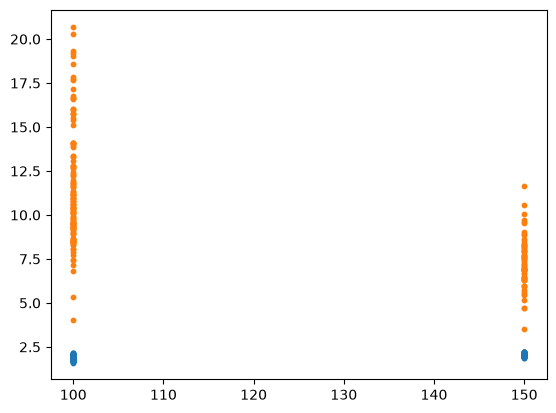

In [53]:
x = df['proctor_diam_mm']
y1 = df['proctor_mdd_g_cm3']
y2 = df['proctor_owc_pct']

plt.scatter(x, y1, s=10)
plt.scatter(x, y2, s=10)

In [54]:
a = df[df['proctor_diam_mm'] < 120]
b = df[df['proctor_diam_mm'] > 120]

In [55]:
temp = df.copy()
temp.fillna(0)
col = temp.columns.drop(['id'])

mat = temp[col].corr().round(5)

mat[['proctor_mdd_g_cm3', 'proctor_owc_pct']]

,proctor_mdd_g_cm3,proctor_owc_pct
psd_size_at_d10_mm,0.12033,-0.52298
psd_size_at_d20_mm,0.16714,-0.43150
psd_size_at_d30_mm,0.20395,-0.40333
psd_size_at_d40_mm,0.31814,-0.44476
psd_size_at_d50_mm,0.42910,-0.49709
psd_size_at_d60_mm,0.52637,-0.55773
psd_size_at_d70_mm,0.59393,-0.59385
psd_size_at_d80_mm,0.62778,-0.61929
psd_size_at_d90_mm,0.63744,-0.64056
psd_size_at_d95_mm,0.63218,-0.63725


In [56]:
for c in df.columns:
    print(df[c].isna().any())

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True
True


In [57]:
df

,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct
0,0,0.136773,0.315214,0.547515,0.933930,1.788142,3.313938,7.214010,12.517275,20.160863,...,51.68,2.068,8.06,150,2.650,NaN,NaN,NaN,NaN,NaN
1,1,0.014579,0.062060,0.119258,0.221877,0.423550,1.022249,2.978369,6.081199,10.622063,...,65.49,2.037,10.42,100,2.690,NaN,NaN,NaN,NaN,1.3
2,2,0.003243,0.022301,0.087024,0.156595,0.217595,0.323793,0.512853,1.546115,10.921905,...,81.40,2.051,10.94,100,2.722,1.400000e-10,30.0,26.45,13.75,NaN
3,3,0.000355,0.000859,0.002080,0.004772,0.009031,0.015228,0.025404,0.041920,0.151357,...,99.61,1.648,20.31,100,2.670,1.100000e-09,3.0,47.63,22.44,4.3
4,4,0.000360,0.004868,0.010546,0.015848,0.021282,0.026753,0.033510,0.042328,0.067946,...,99.28,1.820,15.76,100,2.670,NaN,NaN,NaN,NaN,1.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,0.100777,0.212256,0.341667,0.526610,0.955715,2.339938,4.493148,7.795487,16.941993,...,57.69,2.057,7.90,100,2.650,NaN,NaN,NaN,NaN,NaN
197,197,0.090191,0.126268,0.176777,0.247489,0.346487,0.485085,0.679124,0.950781,1.847298,...,91.10,1.850,8.20,150,2.650,NaN,NaN,NaN,NaN,NaN
198,198,0.176777,0.303513,0.407383,0.559104,0.807431,1.353154,3.230437,9.337932,19.882790,...,65.40,2.059,9.02,150,2.650,NaN,NaN,NaN,NaN,NaN
199,199,0.000390,0.001069,0.002937,0.007530,0.014572,0.031049,0.105558,0.312777,0.629716,...,96.40,1.711,19.03,100,2.650,8.000000e-11,30.0,NaN,NaN,NaN


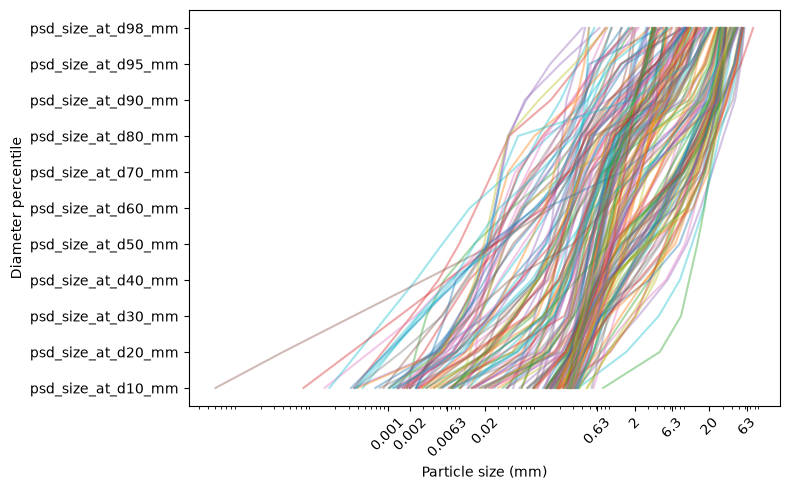

In [58]:
import math
from matplotlib.ticker import FixedFormatter

diam_cols = [
    'psd_size_at_d10_mm',
    'psd_size_at_d20_mm',
    'psd_size_at_d30_mm',
    'psd_size_at_d40_mm',
    'psd_size_at_d50_mm',
    'psd_size_at_d60_mm',
    'psd_size_at_d70_mm',
    'psd_size_at_d80_mm',
    'psd_size_at_d90_mm',
    'psd_size_at_d95_mm',
    'psd_size_at_d98_mm'
]

fig, ax = plt.subplots(figsize=(8, 5))

for _, row in df.iterrows():
    plt.plot(row[diam_cols], diam_cols, alpha=0.4)

plt.ylabel("Diameter percentile")
plt.xlabel("Particle size (mm)")
plt.xticks(rotation=45)
ax.set_xscale('log')
ticks = [0.001, 0.002, 0.0063, 0.02, 0.63, 2,6.3,20,63]
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FixedFormatter(ticks))
plt.tight_layout()
plt.show()

In [69]:
for c in df.columns:
    print(c.ljust(30), len(df[df[c].isna()]) / len(df))

id                             0.0
psd_size_at_d10_mm             0.0
psd_size_at_d20_mm             0.0
psd_size_at_d30_mm             0.0
psd_size_at_d40_mm             0.0
psd_size_at_d50_mm             0.0
psd_size_at_d60_mm             0.0
psd_size_at_d70_mm             0.0
psd_size_at_d80_mm             0.0
psd_size_at_d90_mm             0.0
psd_size_at_d95_mm             0.0
psd_size_at_d98_mm             0.0
psd_has_sedimentation          0.0
psd_passing_at_0_002mm_pct     0.0
psd_passing_at_0_063mm_pct     0.0
psd_passing_at_2mm_pct         0.0
proctor_mdd_g_cm3              0.0
proctor_owc_pct                0.0
proctor_diam_mm                0.0
grain_density_g_cm3            0.0
hyd_cond_kf_m_s                0.6965174129353234
hyd_cond_hyd_gradient          0.6965174129353234
atterberg_liquid_limit_pct     0.8706467661691543
atterberg_plastic_limit_pct    0.8706467661691543
loss_on_ignition_pct           0.6965174129353234


In [60]:
a = df[df['hyd_cond_kf_m_s'].isna()]['id']
b = df[df['hyd_cond_hyd_gradient'].isna()]['id']
c = df[df['loss_on_ignition_pct'].isna()]['id']
d = df[df['atterberg_liquid_limit_pct'].isna()]['id']
e = df[df['atterberg_plastic_limit_pct'].isna()]['id']

# print((d == e).all())
# print((b == c).all())

In [61]:
a = pd.read_csv("./data/synthetic_soil_5000.csv")
b = pd.read_csv('./data/train.csv')

col = df.columns.drop(['id'])

In [62]:
aa = a[col].corr().round(5).rename(columns={
    'proctor_mdd_g_cm3' : 'proctor_mdd_g_cm3_new', 
    'proctor_owc_pct' : 'proctor_owc_pct_new'
})[['proctor_mdd_g_cm3_new', 'proctor_owc_pct_new']]

bb = b[col].corr().round(5)[['proctor_mdd_g_cm3', 'proctor_owc_pct']]

comp = pd.concat([aa, bb], axis=1)
comp['diff_proctor_mdd_g_cm3'] = comp['proctor_mdd_g_cm3'] - comp['proctor_mdd_g_cm3_new']
comp['diff_proctor_owc_pct'] = comp['proctor_owc_pct'] - comp['proctor_owc_pct_new']

comp


,proctor_mdd_g_cm3_new,proctor_owc_pct_new,proctor_mdd_g_cm3,proctor_owc_pct,diff_proctor_mdd_g_cm3,diff_proctor_owc_pct
psd_size_at_d10_mm,0.31142,-0.57677,0.12033,-0.52298,-0.19109,0.05379
psd_size_at_d20_mm,0.36979,-0.54871,0.16714,-0.43150,-0.20265,0.11721
psd_size_at_d30_mm,0.39425,-0.51328,0.20395,-0.40333,-0.19030,0.10995
psd_size_at_d40_mm,0.44230,-0.52641,0.31814,-0.44476,-0.12416,0.08165
psd_size_at_d50_mm,0.47490,-0.55222,0.42910,-0.49709,-0.04580,0.05513
psd_size_at_d60_mm,0.47112,-0.56611,0.52637,-0.55773,0.05525,0.00838
psd_size_at_d70_mm,0.48172,-0.57093,0.59393,-0.59385,0.11221,-0.02292
psd_size_at_d80_mm,0.50616,-0.58179,0.62778,-0.61929,0.12162,-0.03750
psd_size_at_d90_mm,0.57029,-0.62063,0.63744,-0.64056,0.06715,-0.01993
psd_size_at_d95_mm,0.57804,-0.61915,0.63218,-0.63725,0.05414,-0.01810
